<a href="https://colab.research.google.com/github/fralfaro/MAT281/blob/main/docs/labs/lab_06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MAT281 - Laboratorio N°06


**Objetivo**: Aplicar técnicas básicas de **Machine Learning**, desde la preparación de datos hasta el entrenamiento y evaluación de modelos.




<p align="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/thumb/e/ec/Anscombe%27s_quartet_3.svg/1200px-Anscombe%27s_quartet_3.svg.png" width="500"/>
</p>

El **cuarteto de Anscombe** es un ejemplo clásico en estadística que ilustra cómo diferentes conjuntos de datos pueden compartir las mismas propiedades estadísticas, como media, varianza y correlación, pero presentan comportamientos muy distintos cuando se visualizan gráficamente. Cada uno de los cuatro conjuntos consiste en once puntos (x, y) y fue creado por el estadístico F. J. Anscombe en 1973. Esta herramienta resalta la importancia de la visualización de datos para evitar interpretaciones erróneas basadas únicamente en análisis numéricos.

**Descripción del conjunto**

1. **Propiedades estadísticas comunes:** Todos los conjuntos tienen el mismo valor promedio para las variables \(x\) e \(y\), la misma varianza para \(x\) e \(y\), y una correlación lineal idéntica.
2. **Diferencias gráficas:** A pesar de sus similitudes estadísticas, los cuatro conjuntos presentan gráficos muy distintos:
   - El primer conjunto muestra una relación lineal simple.
   - El segundo conjunto tiene una relación no lineal, con una curva clara.
   - El tercer conjunto tiene una relación lineal clara, pero con un punto atípico que influye significativamente.
   - El cuarto conjunto tiene la mayoría de los puntos alineados verticalmente, con un punto atípico que afecta la correlación.

Este cuarteto enfatiza que las estadísticas descriptivas por sí solas pueden no capturar la esencia completa de los datos, subrayando la necesidad de utilizar visualizaciones en cualquier análisis exploratorio de datos.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Configuración de los gráficos
%matplotlib inline
sns.set_theme(style="whitegrid")  # Establece un tema general para los gráficos
sns.set_palette("deep", desat=0.6)
plt.rcParams['figure.figsize'] = (12, 8)  # Ajuste del tamaño de las figuras

# Cargar los datos del cuarteto de Anscombe
data = sns.load_dataset("anscombe")

# Mostrar las primeras filas del conjunto de datos
data.head()

,dataset,x,y
0,I,10.0,8.04
1,I,8.0,6.95
2,I,13.0,7.58
3,I,9.0,8.81
4,I,11.0,8.33


Con base en la información presentada y el análisis realizado, les invitamos a reflexionar y responder las siguientes preguntas. Estas preguntas están diseñadas para profundizar en su comprensión del cuarteto de Anscombe y fomentar un análisis crítico de los datos:



1. Cree un gráfico de dispersión (scatter plot) para cada uno de los cuatro grupos del cuarteto de Anscombe. A partir de la visualización, ¿puede identificar diferencias significativas entre los grupos? ¿Qué características particulares observa en cada uno que sugieren comportamientos distintos?



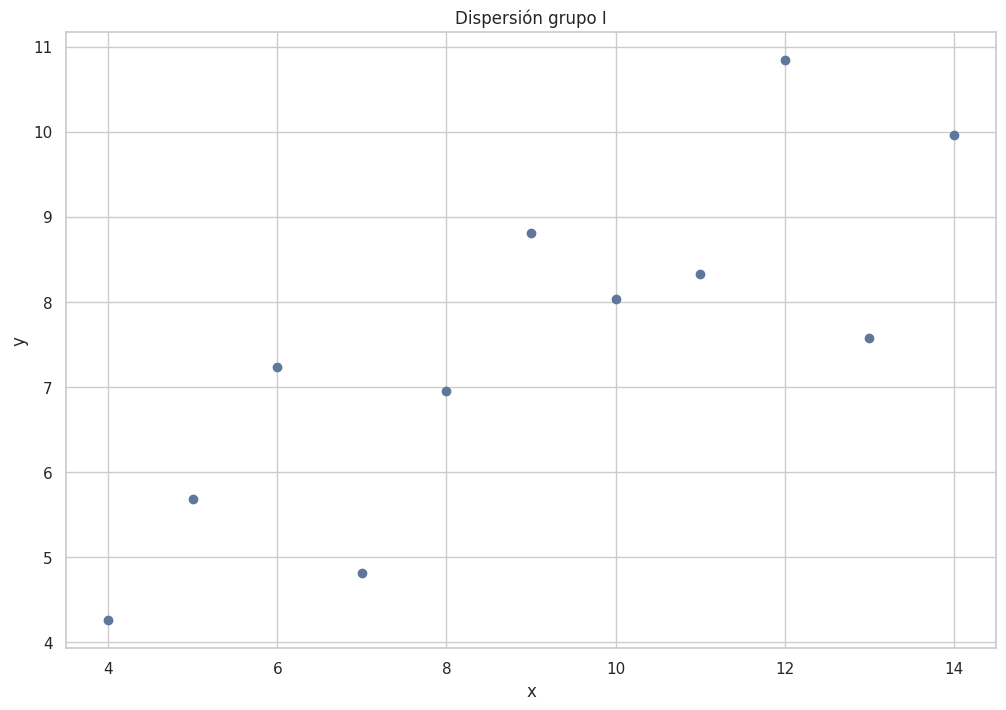

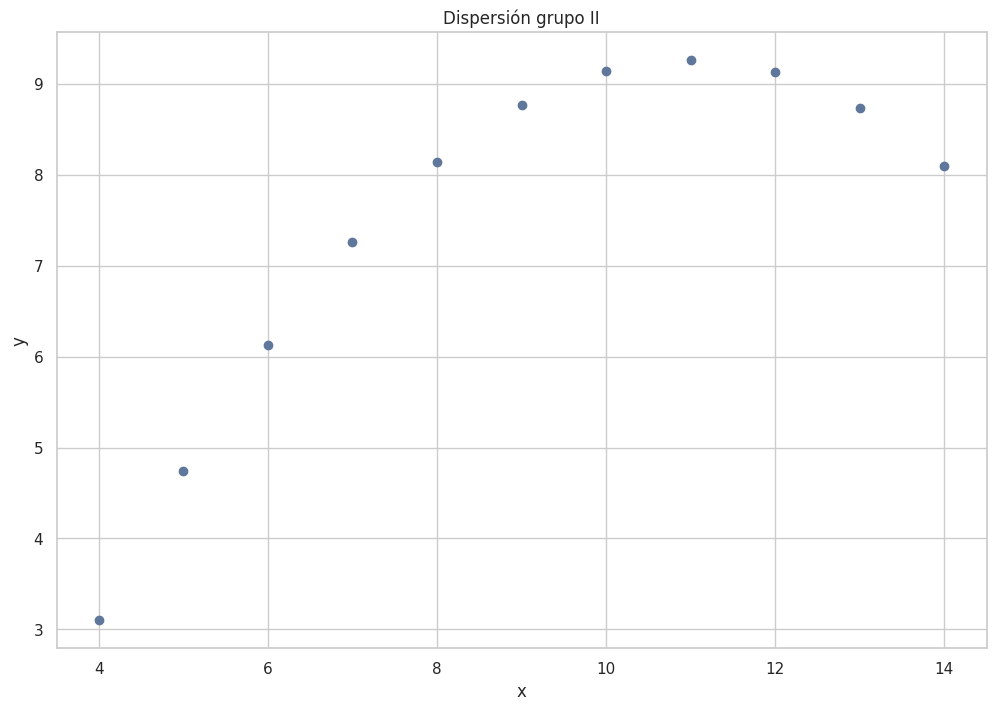

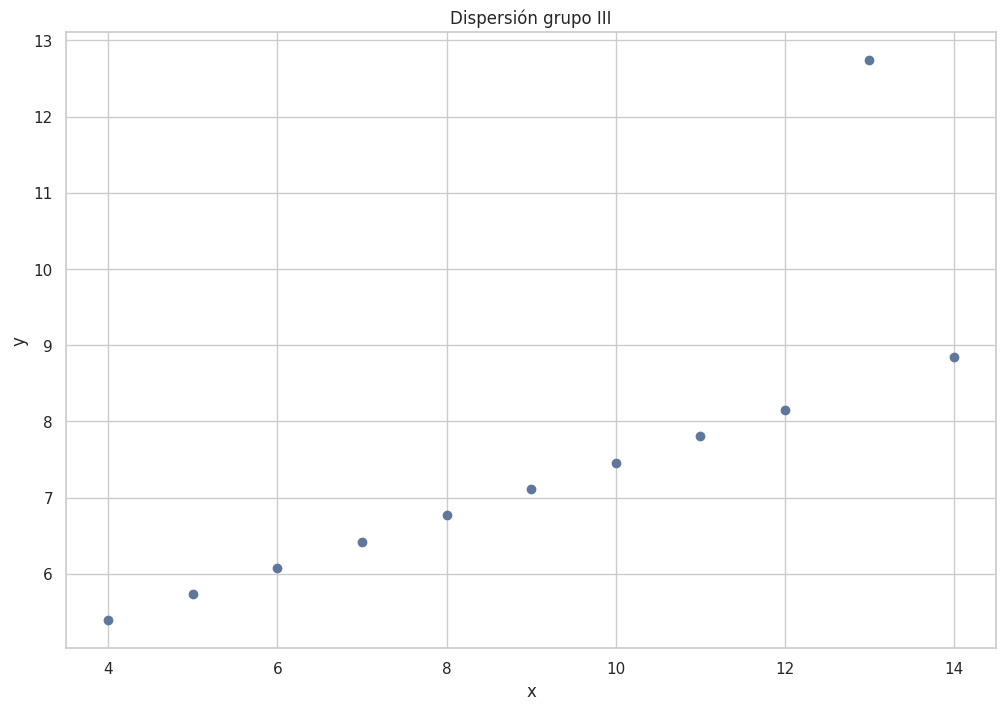

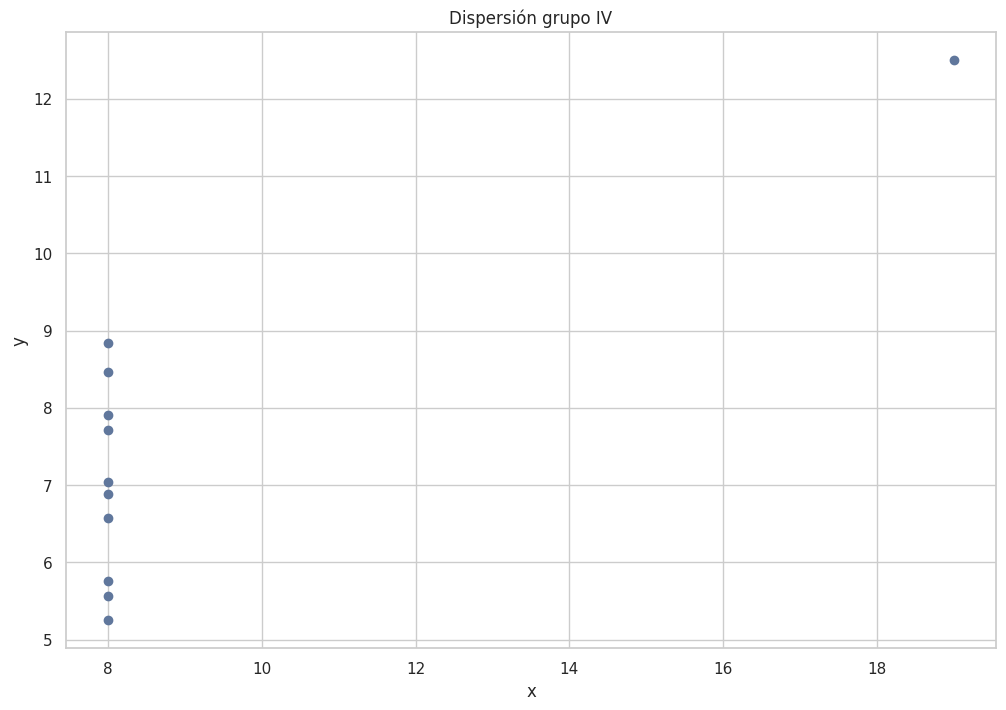

In [8]:
dicc = {}
for i in data['dataset'].unique().tolist():
    dicc[i] = data.loc[data['dataset']==i,['x','y']]
for i in data['dataset'].unique().tolist():
    plt.scatter(dicc[i]['x'],dicc[i]['y'])
    plt.title(f'Dispersión grupo {i}')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.show()

In [ ]:
El conjunto I se ve similar a una función lineal (al menos en la pendiente), el conjunto II se ve como una parabola invertida, el conjunto III se ve como una función lineal (más lineal que I)excepto en el penúltimo dato, y el conjunto IV es casi una línea vertical, a excepción del último punto.

2. Utilice el comando `describe` para generar un resumen de las medidas estadísticas más relevantes para cada uno de los grupos del cuarteto de Anscombe. A partir de estos resultados, interprete las estadísticas obtenidas, destacando las características más significativas de cada grupo y cómo pueden influir en la comprensión de sus respectivas distribuciones.


In [16]:
for i in data['dataset'].unique().tolist():
    print(dicc[f'{i}'].describe())


               x          y
count  11.000000  11.000000
mean    9.000000   7.500909
std     3.316625   2.031568
min     4.000000   4.260000
25%     6.500000   6.315000
50%     9.000000   7.580000
75%    11.500000   8.570000
max    14.000000  10.840000
               x          y
count  11.000000  11.000000
mean    9.000000   7.500909
std     3.316625   2.031657
min     4.000000   3.100000
25%     6.500000   6.695000
50%     9.000000   8.140000
75%    11.500000   8.950000
max    14.000000   9.260000
               x          y
count  11.000000  11.000000
mean    9.000000   7.500000
std     3.316625   2.030424
min     4.000000   5.390000
25%     6.500000   6.250000
50%     9.000000   7.110000
75%    11.500000   7.980000
max    14.000000  12.740000
               x          y
count  11.000000  11.000000
mean    9.000000   7.500909
std     3.316625   2.030579
min     8.000000   5.250000
25%     8.000000   6.170000
50%     8.000000   7.040000
75%     8.000000   8.190000
max    19.000000  12

In [ ]:
En relación a la media y la desviación estándar, todos los conjuntos parecen ser iguales(numéricamente). Pero estos datos varían en cada grupo sus máximos, mínimos y cuartiles, de esto es posible ver que gráficamente  el primer grupo es lineal, el segundo es una curva, el tercero es lineal con un outliner y el cuarto es vertical con un punto extremo. Esto remarca la importancia de no solo guiarse con los números, sino que los gráficos son importantes a la hora de comprender la naturaleza de los datos.

3. Ajuste un modelo de regresión lineal para cada grupo utilizando **sklearn**. Calcule las métricas de evaluación, como el error cuadrático medio (MSE) y R², y grafique los resultados de la regresión. Interprete los resultados y su impacto en la calidad del ajuste.



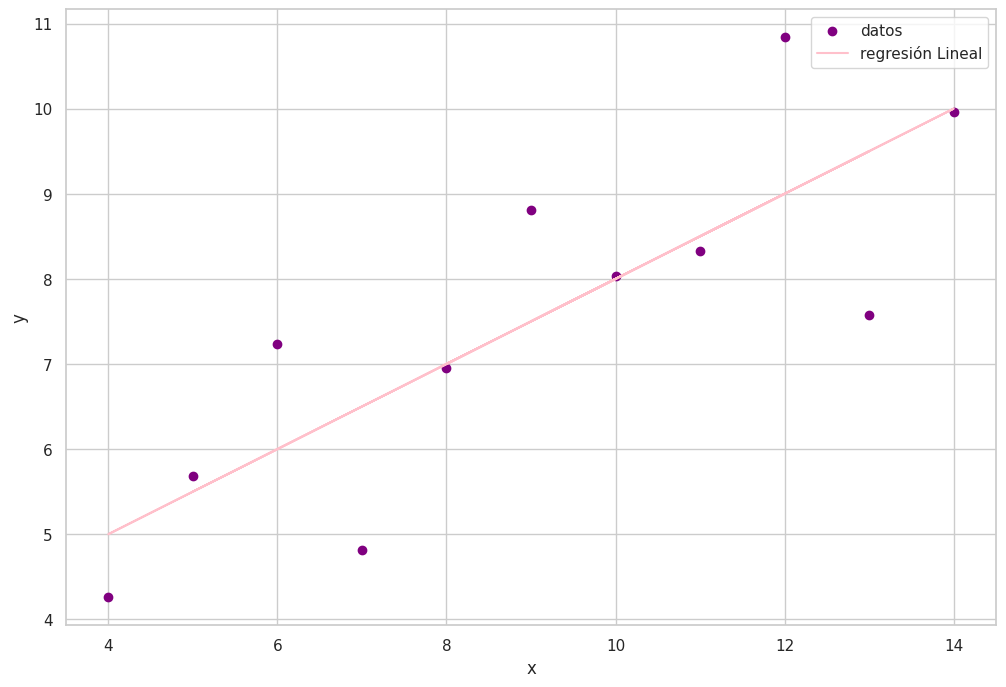

R cuadrado: 0.6665424595087748
MSE: 1.2511536363636366



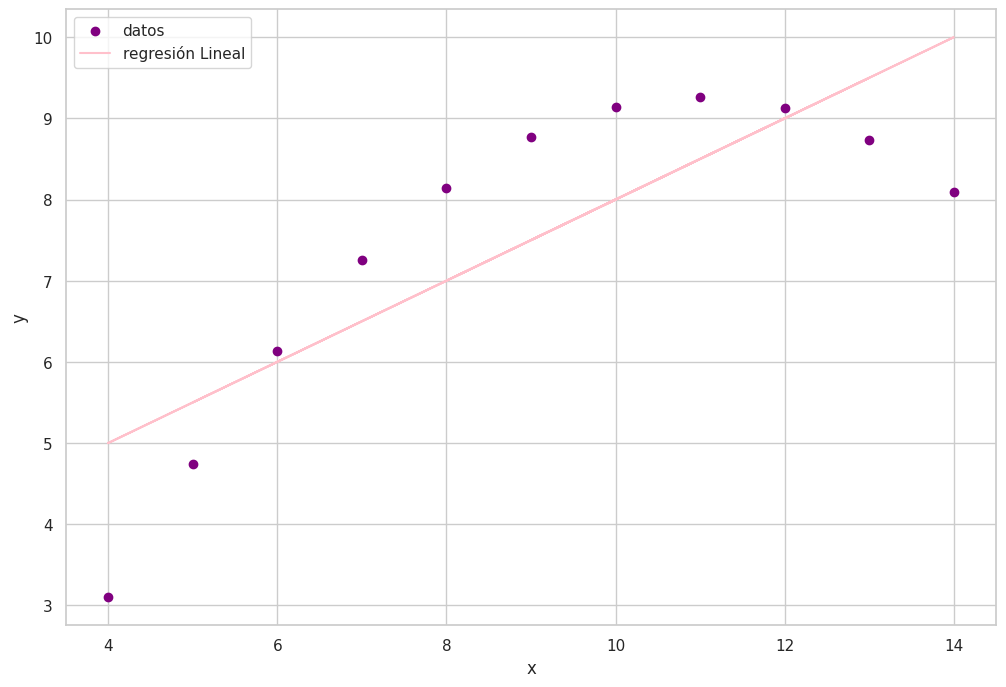

R cuadrado: 0.6662420337274844
MSE: 1.2523900826446281



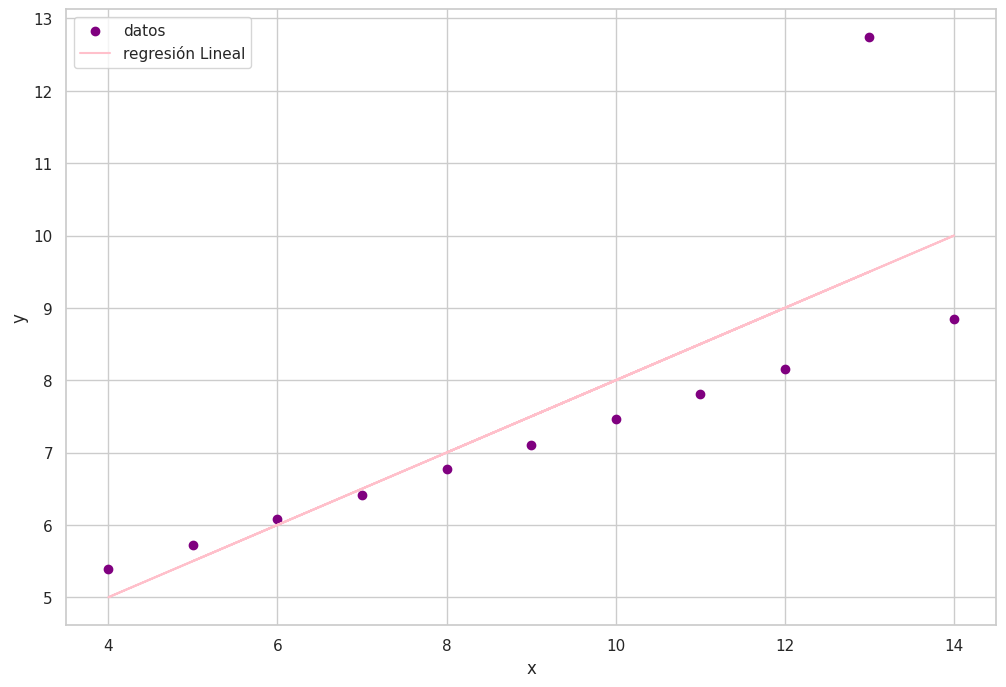

R cuadrado: 0.6663240410665592
MSE: 1.2505628925619836



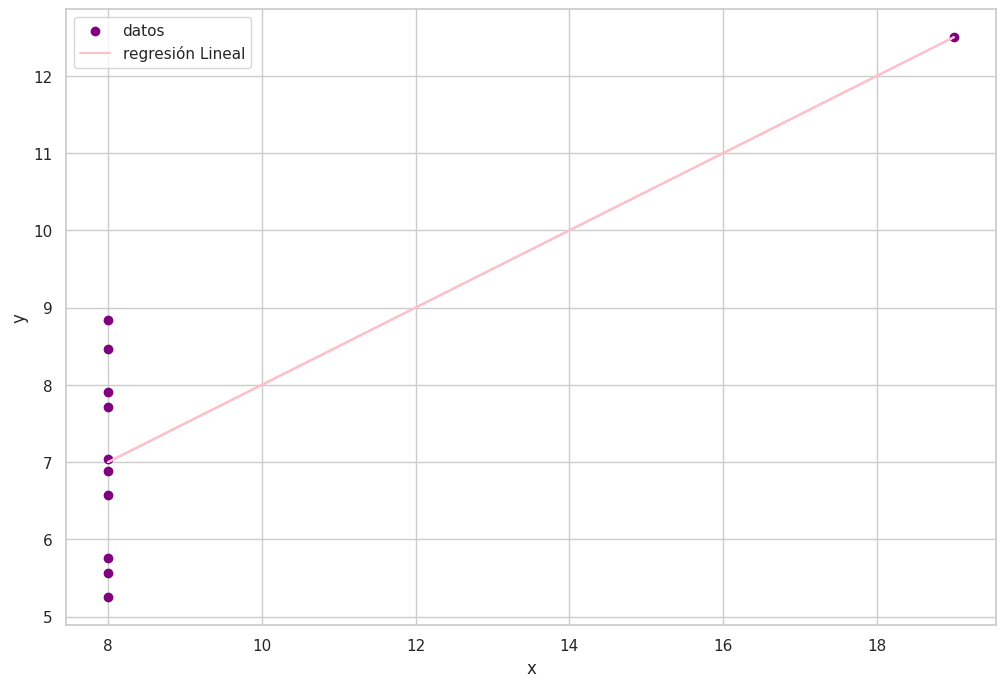

R cuadrado: 0.6667072568984653
MSE: 1.249317272727273



In [20]:
from sklearn.model_selection import train_test_split

for i in data['dataset'].unique().tolist():
    x = dicc[i][['x']]
    y = dicc[i]['y']
    LR = LinearRegression()
    LR.fit(x,y)
    xfit = x.copy()
    yfit = LR.predict(xfit)
    mse = mean_squared_error(y,yfit)
    R2  = r2_score(y,yfit)
    plt.scatter(x, y, label= 'datos', color='purple')
    plt.plot(xfit,yfit,label='regresión Lineal',color='pink')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.show()
    print(f'R cuadrado: {R2}\nMSE: {mse}\n')

In [ ]:
Los indicadores estadisticos muestran resultados casi identicos en todos los conjuntos de datos. Esto es debido a que estos se calculan usando metodos que involucran la media, la desviación estandar y otros estadisticos que anteriormente notamos, entre gráficos estos datos son prrácticamente iguales. El gráfico I y III se adaptan bien a la regresión lineal, a diferencia de los gráficos II y IV, debido a sus formas gráficas nalizadas anteriormente.

4. Es evidente que el ajuste lineal no es adecuado para algunos grupos. Existen diversas estrategias para abordar este problema, como eliminar outliers o emplear diferentes modelos de regresión. Identifique una estrategia que podría mejorar el ajuste del modelo de regresión lineal y, si lo considera necesario, implemente otros modelos alternativos para aquellos casos donde el ajuste lineal resulte inadecuado.

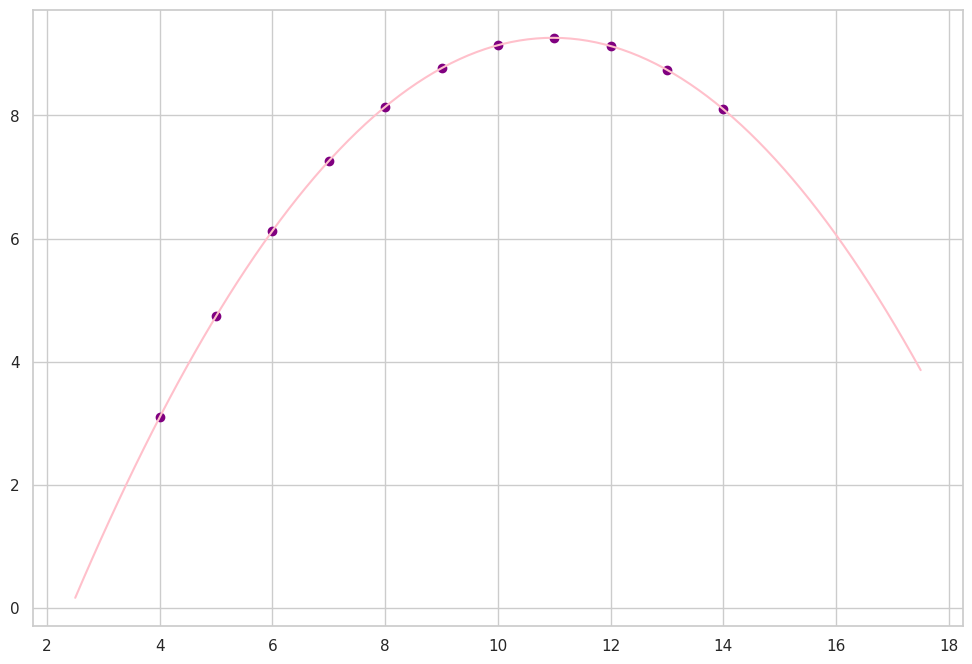

MSE: 0.31710740951360333



In [33]:
#Utilizaremos otro modelo para el conjunto II,ya que este posee peor MSE (más lejos del cero). Lo cambiaremos a uno específico para funciones cuadráticas.
from sklearn.preprocessing import PolynomialFeatures
poly =  PolynomialFeatures(degree=4,include_bias=False)
data_II = dicc['II']
x = data_II['x'].values
y = data_II['y'].values
model = np.poly1d(np.polyfit(x,y,2))
polyline = np.linspace(2.5,17.5,100)
mse = mean_squared_error(y,model(y))
plt.scatter(x, y, label= 'datos', color='purple')
plt.plot(polyline, model(polyline), label='regresión Lineal',color='pink')
plt.show()
print(f'MSE: {mse}\n')
